# Planar unicycle

Section V-A of the paper on the Warp backend: Table I and Fig. 4. Warp on the CPU in float64, no JAX; about 2.5 minutes on an AMD Ryzen 9 7950X.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import numpy as np
import warp as wp
from IPython.display import Markdown
from matplotlib.patches import Circle

from sparsemax_dstl.stl import compile_formula
from sparsemax_dstl.tasks import planar, planar_al
from sparsemax_dstl.tasks import planar_disk as D
from sparsemax_dstl.tasks.planar_warp import WarpChain
from sparsemax_dstl.warp import Evaluator, matched_param

wp.config.log_level = wp.LOG_WARNING
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
Path("out").mkdir(exist_ok=True)


def table(header, rows):
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    lines += ["| " + " | ".join(str(x) for x in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))


def shown(x):
    if abs(x) >= 0.001:
        return round(x, 4)
    return "< 0.001" if x >= 0 else "> -0.001"

The specification of Equation (18), $\varphi = (\neg\mathrm{Red}\ \mathbf{U}_{I_1}\,\mathrm{Green}) \wedge \mathbf{F}_{I_2}\mathbf{G}_{[0,2]}\,\mathrm{Blue} \wedge \mathbf{G}\,\neg\mathrm{Obstacle} \wedge \mathbf{G}\,\mathrm{Boundary}$, and the commands of $S_1$ and $S_2$ at the 3 s wait.

In [2]:
eps = 0.1
u1, u2, tm = D.trajectories(30, eps)
T = tm["T"]
spec, conj, until = D.specification(tm["a1"], tm["b1"], tm["a2"], tm["b2"], T)
z1 = planar.rollout(D.Z0, u1)
z2 = planar.rollout(D.Z0, u2)
print(T, "samples of", D.H, "s; I1 =", (tm["a1"], tm["b1"]), "and I2 =", (tm["a2"], tm["b2"]), "in samples")

447 samples of 0.1 s; I1 = (236, 256) and I2 = (366, 426) in samples


Fig. 4(a): the regions, $S_1$ and $S_2$.

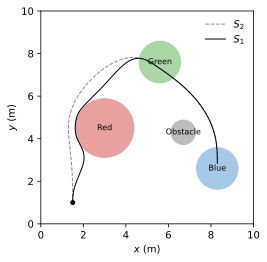

In [3]:
colors = {"Red": "#e8a0a0", "Green": "#a9d8a6", "Blue": "#a6c8e8", "Obstacle": "#bdbdbd"}
fig, ax = plt.subplots(figsize=(3.6, 3.6), layout="constrained")
for name, (cx, cy, r) in zip(D.NAMES, D.REGIONS):
    ax.add_patch(Circle((cx, cy), r, color=colors[name], lw=0))
    ax.text(cx, cy, name, ha="center", va="center", fontsize=8)
ax.plot(z2[:, 0], z2[:, 1], "--", color="0.55", lw=1, label="$S_2$")
ax.plot(z1[:, 0], z1[:, 1], "k", lw=1, label="$S_1$")
ax.plot(D.Z0[0], D.Z0[1], "ko", ms=4)
ax.set(xlim=(0, 10), ylim=(0, 10), aspect="equal", xlabel="$x$ (m)", ylabel="$y$ (m)")
ax.legend(frameon=False)
fig.savefig("out/unicycle_trajectories.svg")
fig.savefig("out/unicycle_trajectories.pdf")

The value of $\varphi$ at $t = 0$ on $S_1$ and $S_2$ from the Warp evaluator, with every smoothing at the error $\varepsilon = 0.1$ m per node (Equation (15)).

In [4]:
measures = {"exact": "exact", "lse_plain": "plain LSE", "lse": "sound LSE", "gm_pm01": "GMR (0, 1)", "gm_pm10": "GMR (-10, 10)", "sparsemax": "sparsemax"}
smooth = [m for m in measures if m != "exact"]


def evaluator(formula, T, measure, n):
    prog = compile_formula(formula, T, reads=[(formula, [0])])
    param = None if measure == "exact" else matched_param(prog, measure, eps)
    return Evaluator(prog, measure, param, n, wp.float64, "cpu", P=8)


S = wp.array(D.scores(np.stack([z1, z2])[..., :2]), dtype=wp.float64, device="cpu")
value = {m: evaluator(spec, T, m, 2).value(S).numpy()[:, 0] for m in measures}

The weight on the samples of $S_1$ inside Red: the gradient of the until at $t = 0$ with respect to $\neg\mathrm{Red}$, summed over those samples, at waits of 3, 12, 48 and 130 s.

In [5]:
def weight(wait, measure):
    u, _, tm = D.trajectories(wait, eps)
    S = D.scores(planar.rollout(D.Z0, u)[None, :, :2])
    until = D.specification(tm["a1"], tm["b1"], tm["a2"], tm["b2"], tm["T"])[2]
    rho, G = evaluator(until, tm["T"], measure, 1).gradient(wp.array(S, dtype=wp.float64, device="cpu"))
    inside = (S[0, :, 0] > 0) & (np.arange(tm["T"]) <= tm["b1"])
    return -G.numpy()[0, inside, 0].sum()


w = {m: [weight(wait, m) for wait in (30, 120, 480, 1300)] for m in smooth}

Table I, columns "value" and "weight on $S_1$".

In [6]:
rows = [[measures[m]] + [round(x, 4) for x in list(value[m]) + w.get(m, [])] for m in measures]
table(["measure", "$S_1$", "$S_2$", "weight at 3 s", "12 s", "48 s", "130 s"], rows)

| measure | $S_1$ | $S_2$ | weight at 3 s | 12 s | 48 s | 130 s |
|---|---|---|---|---|---|---|
| exact | -0.015 | 0.3 |
| plain LSE | 0.024 | 0.3572 | 0.6817 | 0.5202 | 0.3077 | 0.188 |
| sound LSE | -0.076 | 0.2575 | 0.6817 | 0.5202 | 0.3077 | 0.188 |
| GMR (0, 1) | -0.0001 | 1.6855 | 0.0425 | 0.0312 | 0.0151 | 0.0069 |
| GMR (-10, 10) | -0.0092 | 0.4927 | 0.7138 | 0.692 | 0.6435 | 0.5953 |
| sparsemax | -0.1096 | 0.2137 | 1.0 | 1.0 | 1.0 | 1.0 |

The effort $E$ minimized subject to every conjunct's smoothed robustness being at least $c$ (Equation (4)), for $c = 0$ and $c = 0.2$ m: 400 updates of the augmented Lagrangian solver from $S_1$ and $S_2$ on the Warp chain (rollout, predicates and robustness as Warp kernels).

In [7]:
V0 = np.stack([u1, u2]) / D.U_MAX
levels = (0.0, 0.2)


def optimize(measure, c):
    chain = WarpChain(conj, T, measure, eps, D.Z0, D.REGIONS, 2)
    return planar_al.solve(chain, V0, budget=400, lam=0.01, delta=c, alpha0=0.002)[0]


V = {(m, c): optimize(m, c) for m in smooth for c in levels}

Exact robustness $\rho$ and effort $E$ of the returned trajectories; a value in $(0, 0.001)$ is shown as < 0.001, as in Table I. The first two columns are Table I's "returned $\rho$", printed there from the JAX chain (`jax_backend.ipynb`).

In [8]:
returned = {(m, c, g): D.summary(V[m, c][g], tm, eps) for m, c in V for g in (0, 1)}
rows = [[measures[m]] + [shown(returned[m, c, g][1][k]) for k in ("exact", "effort_E") for g in (0, 1) for c in levels] for m in smooth]
header = ["from $S_1$, $c = 0$", "from $S_1$, $c = 0.2$", "from $S_2$, $c = 0$", "from $S_2$, $c = 0.2$"]
table(["measure"] + ["$\\rho$ " + h for h in header] + ["$E$ " + h for h in header], rows)

| measure | $\rho$ from $S_1$, $c = 0$ | $\rho$ from $S_1$, $c = 0.2$ | $\rho$ from $S_2$, $c = 0$ | $\rho$ from $S_2$, $c = 0.2$ | $E$ from $S_1$, $c = 0$ | $E$ from $S_1$, $c = 0.2$ | $E$ from $S_2$, $c = 0$ | $E$ from $S_2$, $c = 0.2$ |
|---|---|---|---|---|---|---|---|---|
| plain LSE | -0.0586 | 0.1461 | -0.0933 | 0.1102 | 0.1631 | 0.178 | 0.1328 | 0.1475 |
| sound LSE | 0.0445 | 0.2183 | 0.0343 | 0.2471 | 0.1715 | 0.1799 | 0.1409 | 0.1605 |
| GMR (0, 1) | < 0.001 | < 0.001 | < 0.001 | < 0.001 | 0.1815 | 0.186 | 0.1615 | 0.1472 |
| GMR (-10, 10) | < 0.001 | 0.1415 | > -0.001 | 0.1464 | 0.1692 | 0.1812 | 0.1374 | 0.1509 |
| sparsemax | 0.0866 | 0.2482 | 0.0876 | 0.2894 | 0.1764 | 0.1858 | 0.1443 | 0.1617 |

Fig. 4(b): distance from Red of the trajectories returned at $c = 0$ from $S_1$ (dotted).

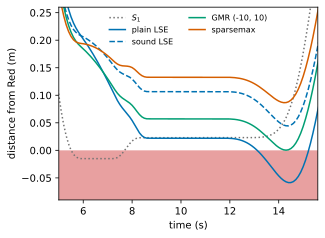

In [9]:
def distance(z):
    return -D.scores(z[:, :2])[:, 0]


t = D.H * np.arange(T)
fig, ax = plt.subplots(figsize=(4.4, 3.2), layout="constrained")
ax.axhspan(-0.09, 0, color="#e8a0a0", lw=0)
ax.plot(t, distance(z1), ":", color="0.45", label="$S_1$")
ax.plot(t, distance(returned["lse_plain", 0.0, 0][0]), color="#0072b2", label="plain LSE")
ax.plot(t, distance(returned["lse", 0.0, 0][0]), "--", color="#0072b2", label="sound LSE")
ax.plot(t, distance(returned["gm_pm10", 0.0, 0][0]), color="#009e73", label="GMR (-10, 10)")
ax.plot(t, distance(returned["sparsemax", 0.0, 0][0]), color="#d55e00", label="sparsemax")
ax.set(xlim=(5, 15.6), ylim=(-0.09, 0.26), xlabel="time (s)", ylabel="distance from Red (m)")
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center")
fig.savefig("out/unicycle_returned.svg")
fig.savefig("out/unicycle_returned.pdf")